# Model Training

Importing packages

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#importing Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


Loading dataset

In [107]:
df=pd.read_csv("/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/notebook/dataset/Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [108]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [110]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].dtype)

float64


In [111]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [112]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)


In [113]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

***Converting Churn column into numeric as Yes:1, No:0.***

In [114]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [115]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

Droping the column Customer ID

In [116]:
df=df.drop(['customerID'],axis=1)

## Preparing X and Y variables

In [117]:
y = df['Churn']

In [118]:
X = df.drop('Churn',axis=1)

In [119]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [120]:
cat_feat = X.select_dtypes(include='object').columns
num_feat = X.select_dtypes(exclude='object').columns

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocesser = ColumnTransformer(
    [
        ("StandardScaler", numerical_transformer, num_feat),
        ("OneHotEncoder",categorical_transformer,cat_feat)
    ]
)

/var/folders/k3/qn_n2f410tx2xcgq5g6q45rr0000gn/T/ipykernel_54242/2434510082.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_feat = X.select_dtypes(include='object').columns


In [121]:
X = preprocesser.fit_transform(X)

In [122]:
X.shape

(7043, 45)

## Splitting Train and Test Data

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((5634, 45), (1409, 45))

In [150]:
def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, precision, recall, f1

## Model Training

In [155]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "L1 Logistic (Lasso)": LogisticRegression(penalty='l1', solver="liblinear", max_iter=1000),
    "L2 Logistic (Ridge)": LogisticRegression(penalty='l2', solver="lbfgs", max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVC": SVC(),
    "Decision Tress": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encode=False,eval_matric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=False),
    "AdaBoost": AdaBoostClassifier()
}

In [156]:
params = {

    "Decision Tree": {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": [3, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, 20],
        "criterion": ["gini", "entropy"]
    },

    "Gradient Boosting": {
        "learning_rate": [0.1, 0.05, 0.01],
        "n_estimators": [50, 100, 200],
        "subsample": [0.6, 0.8, 1.0],
        "max_depth": [3, 5]
    }, 

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100]
    },

    "L1 Logistic (Lasso)": {
        "C": [0.01, 0.1, 1, 10]
    },

    "L2 Logistic (Ridge)": {
        "C": [0.01, 0.1, 1, 10]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },

    "SVC": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },

    "XGBoost": {
        "learning_rate": [0.01, 0.05, 0.1],
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7],
        "subsample": [0.8, 1.0]
    },

    "CatBoost": {
        "depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        "iterations": [50, 100, 200]
    },

    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    }
}


In [157]:
from sklearn.model_selection import GridSearchCV

model_list = []
train_accuracy_list = []
test_accuracy_list = []

for i in range(len(list(models))):

    model_name = list(models.keys())[i]
    model = list(models.values())[i]
    if model_name in params and params[model_name]:

        gs = GridSearchCV(
            estimator=model,
            param_grid=params[model_name],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )

        gs.fit(X_train, y_train)
        best_model = gs.best_estimator_
        print(f"Best Parameters for {model_name}:")
        print(gs.best_params_)
        print("=" * 50)

    else:
        best_model = model
        best_model.fit(X_train, y_train)

 
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

   
    train_acc, train_prec, train_rec, train_f1 = evaluate_model(y_train, y_train_pred)
    test_acc, test_prec, test_rec, test_f1 = evaluate_model(y_test, y_test_pred)

    model_list.append(model_name)
    train_accuracy_list.append(train_acc)
    test_accuracy_list.append(test_acc)

    print(model_name)

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(train_acc))
    print("- Precision: {:.4f}".format(train_prec))
    print("- Recall: {:.4f}".format(train_rec))
    print("- F1 Score: {:.4f}".format(train_f1))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Accuracy: {:.4f}".format(test_acc))
    print("- Precision: {:.4f}".format(test_prec))
    print("- Recall: {:.4f}".format(test_rec))
    print("- F1 Score: {:.4f}".format(test_f1))

    print('=' * 35)
    print('\n\n')


Best Parameters for Logistic Regression:
{'C': 10}
Logistic Regression
Model performance for Training set
- Accuracy: 0.8019
- Precision: 0.6540
- Recall: 0.5394
- F1 Score: 0.5912
----------------------------------
Model performance for Test set
- Accuracy: 0.8190
- Precision: 0.6821
- Recall: 0.5925
- F1 Score: 0.6341





/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linea

Best Parameters for L1 Logistic (Lasso):
{'C': 10}
L1 Logistic (Lasso)
Model performance for Training set
- Accuracy: 0.8023
- Precision: 0.6548
- Recall: 0.5401
- F1 Score: 0.5919
----------------------------------
Model performance for Test set
- Accuracy: 0.8190
- Precision: 0.6821
- Recall: 0.5925
- F1 Score: 0.6341



Best Parameters for L2 Logistic (Ridge):
{'C': 10}
L2 Logistic (Ridge)
Model performance for Training set
- Accuracy: 0.8019
- Precision: 0.6540
- Recall: 0.5394
- F1 Score: 0.5912
----------------------------------
Model performance for Test set
- Accuracy: 0.8190
- Precision: 0.6821
- Recall: 0.5925
- F1 Score: 0.6341



K-Nearest Neighbors
Model performance for Training set
- Accuracy: 0.8337
- Precision: 0.7024
- Recall: 0.6484
- F1 Score: 0.6743
----------------------------------
Model performance for Test set
- Accuracy: 0.7729
- Precision: 0.5738
- Recall: 0.5523
- F1 Score: 0.5628





/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linea

Best Parameters for SVC:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVC
Model performance for Training set
- Accuracy: 0.8140
- Precision: 0.7078
- Recall: 0.5100
- F1 Score: 0.5929
----------------------------------
Model performance for Test set
- Accuracy: 0.8084
- Precision: 0.6807
- Recall: 0.5201
- F1 Score: 0.5897



Decision Tress
Model performance for Training set
- Accuracy: 0.9986
- Precision: 0.9987
- Recall: 0.9960
- F1 Score: 0.9973
----------------------------------
Model performance for Test set
- Accuracy: 0.7111
- Precision: 0.4564
- Recall: 0.4772
- F1 Score: 0.4666



RandomForest
Model performance for Training set
- Accuracy: 0.9986
- Precision: 0.9980
- Recall: 0.9967
- F1 Score: 0.9973
----------------------------------
Model performance for Test set
- Accuracy: 0.7921
- Precision: 0.6515
- Recall: 0.4611
- F1 Score: 0.5400



GradientBoosting
Model performance for Training set
- Accuracy: 0.8268
- Precision: 0.7226
- Recall: 0.5642
- F1 Score: 0.6336
----------

/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_matric", "use_label_encode" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_matric", "use_label_encode" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_matric", "use_label_encode" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/pavankumarb/Documents/My Learning/IBMCustomer

Best Parameters for XGBoost:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
XGBoost
Model performance for Training set
- Accuracy: 0.8110
- Precision: 0.6869
- Recall: 0.5294
- F1 Score: 0.5980
----------------------------------
Model performance for Test set
- Accuracy: 0.8126
- Precision: 0.6873
- Recall: 0.5362
- F1 Score: 0.6024



Best Parameters for CatBoost:
{'depth': 6, 'iterations': 200, 'learning_rate': 0.01}
CatBoost
Model performance for Training set
- Accuracy: 0.8115
- Precision: 0.7002
- Recall: 0.5074
- F1 Score: 0.5884
----------------------------------
Model performance for Test set
- Accuracy: 0.8098
- Precision: 0.6895
- Recall: 0.5121
- F1 Score: 0.5877



Best Parameters for AdaBoost:
{'learning_rate': 1.0, 'n_estimators': 200}
AdaBoost
Model performance for Training set
- Accuracy: 0.8026
- Precision: 0.6627
- Recall: 0.5227
- F1 Score: 0.5845
----------------------------------
Model performance for Test set
- Accuracy: 0.8141
- Prec

In [158]:
results_df = pd.DataFrame({
    "Model Name": model_list,
    "Train Accuracy": train_accuracy_list,
    "Test Accuracy": test_accuracy_list,
    "Gap": [abs(train - test) for train, test in zip(train_accuracy_list, test_accuracy_list)]
})

results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)


,Model Name,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,0.801917,0.819021,0.017104
1,L1 Logistic (Lasso),0.802272,0.819021,0.016749
2,L2 Logistic (Ridge),0.801917,0.819021,0.017104
3,AdaBoost,0.802627,0.814053,0.011426
4,XGBoost,0.810969,0.812633,0.001664
5,GradientBoosting,0.826766,0.809794,0.016972
6,CatBoost,0.811502,0.809794,0.001707
7,SVC,0.813987,0.808375,0.005612
8,RandomForest,0.998580,0.792051,0.206529
9,K-Nearest Neighbors,0.833688,0.772889,0.060800


In [159]:
results_df.sort_values(by="Gap", ascending=True).reset_index(drop=True)

,Model Name,Train Accuracy,Test Accuracy,Gap
0,XGBoost,0.810969,0.812633,0.001664
1,CatBoost,0.811502,0.809794,0.001707
2,SVC,0.813987,0.808375,0.005612
3,AdaBoost,0.802627,0.814053,0.011426
4,L1 Logistic (Lasso),0.802272,0.819021,0.016749
5,GradientBoosting,0.826766,0.809794,0.016972
6,Logistic Regression,0.801917,0.819021,0.017104
7,L2 Logistic (Ridge),0.801917,0.819021,0.017104
8,K-Nearest Neighbors,0.833688,0.772889,0.060800
9,RandomForest,0.998580,0.792051,0.206529


High Test Accuracy + Minimum Gap (Generalization Error)

✔ Best model selection is not only about highest accuracy, but about balancing performance and generalization on unseen data.
✔ Train–test gap is a key indicator of overfitting; a smaller gap means the model is more stable and reliable in real-world scenarios.
✔ The ideal model is the one with high test accuracy and minimal gap, proving it can both learn patterns and generalize effectively.

In [160]:
best_model_result = evaluate_models(X_train, y_train, X_test, y_test, models, params)

print("Best Model:", best_model_result["best_model_name"])
print("Best Params:", best_model_result["best_params"])
print("Train Accuracy:", best_model_result["best_train_accuracy"])
print("Test Accuracy:", best_model_result["best_test_accuracy"])
print("Gap:", best_model_result["best_gap"])


/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use '

Best Model: L1 Logistic (Lasso)
Best Params: {'C': 10}
Train Accuracy: 0.8022719204827831
Test Accuracy: 0.8190205819730305
Gap: 0.016748661490247452


In [162]:
def evaluate_models(X_train, y_train, X_test, y_test, models, params):
    try:
        model_names = []
        train_acc_list = []
        test_acc_list = []
        gap_list = []

        best_index = 0
        best_trained_model = None
        best_params = None

        for i, (model_name, model) in enumerate(models.items()):

            # Train model
            if model_name in params and params[model_name]:
                gs = GridSearchCV(
                    estimator=model,
                    param_grid=params[model_name],
                    cv=3,
                    scoring='accuracy',
                    n_jobs=-1
                )
                gs.fit(X_train, y_train)
                trained_model = gs.best_estimator_
                model_params = gs.best_params_
            else:
                trained_model = model
                trained_model.fit(X_train, y_train)
                model_params = trained_model.get_params()

            # Prediction
            train_pred = trained_model.predict(X_train)
            test_pred = trained_model.predict(X_test)

            # Accuracy
            train_acc = accuracy_score(y_train, train_pred)
            test_acc = accuracy_score(y_test, test_pred)

            gap = abs(train_acc - test_acc)

            # store results
            model_names.append(model_name)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)
            gap_list.append(gap)

            # best model selection
            best_gap = gap_list[best_index]
            best_test_acc = test_acc_list[best_index]

            if (test_acc > best_test_acc) or \
               (test_acc == best_test_acc and gap < best_gap):

                best_index = i
                best_trained_model = trained_model
                best_params = model_params

        return {
            "best_model": best_trained_model,
            "best_model_name": model_names[best_index],
            "best_params": best_params,
            "best_train_accuracy": train_acc_list[best_index],
            "best_test_accuracy": test_acc_list[best_index],
            "best_gap": gap_list[best_index]
        }

    except Exception as e:
        raise CustomException(e)


In [163]:

best_model=best_model_result["best_model"]
best_model.fit(X_train,y_train)

y_train_pred=best_model.predict(X_train)
y_test_pred=best_model.predict(X_test)

train_acc, train_prec, train_rec, train_f1 = evaluate_model(y_train, y_train_pred)
test_acc, test_prec, test_rec, test_f1 = evaluate_model(y_test, y_test_pred)

print("Best_model :", best_model_result["best_model_name"])
print('----------------------------------')
print('Model performance for Training set')
print("- Accuracy: {:.4f}".format(train_acc))
print("- Precision: {:.4f}".format(train_prec))
print("- Recall: {:.4f}".format(train_rec))
print("- F1 Score: {:.4f}".format(train_f1))
print('----------------------------------')
print('Model performance for Test set')
print("- Accuracy: {:.4f}".format(test_acc))
print("- Precision: {:.4f}".format(test_prec))
print("- Recall: {:.4f}".format(test_rec))
print("- F1 Score: {:.4f}".format(test_f1))
print('='*35)
print('\n\n')



/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pavankumarb/Documents/My Learning/IBMCustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best_model : L1 Logistic (Lasso)
----------------------------------
Model performance for Training set
- Accuracy: 0.8023
- Precision: 0.6548
- Recall: 0.5401
- F1 Score: 0.5919
----------------------------------
Model performance for Test set
- Accuracy: 0.8190
- Precision: 0.6821
- Recall: 0.5925
- F1 Score: 0.6341





Plot y_pred and y_test

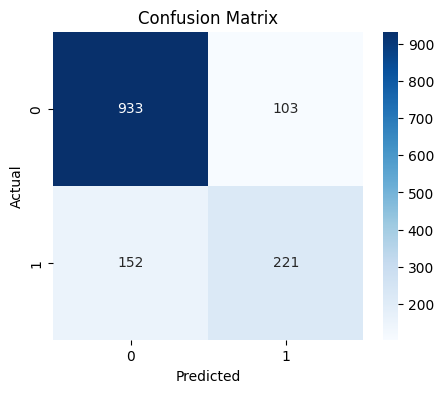

In [164]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [165]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409



Difference between Actual and Predicted Values

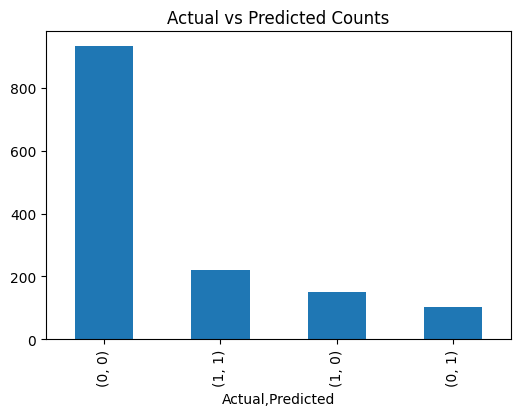

In [166]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

comparison_df.value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Actual vs Predicted Counts")
plt.show()


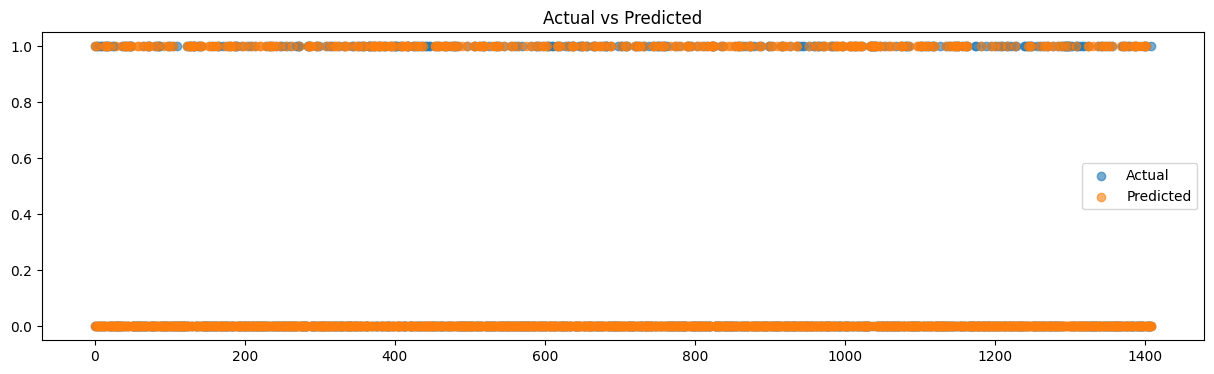

In [167]:
plt.figure(figsize=(15,4))
plt.scatter(range(len(y_test)), y_test, label='Actual', alpha=0.6)
plt.scatter(range(len(y_test_pred)), y_test_pred, label='Predicted', alpha=0.6)
plt.legend()
plt.title("Actual vs Predicted")
plt.show()


ROC

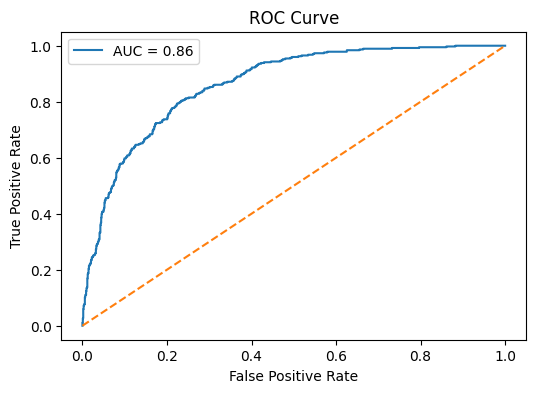

In [168]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
